In [12]:
%%javascript

document.body.style.backgroundColor = 'white'

document.querySelectorAll('.prompt_container,.output_prompt,.out_prompt_overlay').forEach(el => el.remove())

<IPython.core.display.Javascript object>

In [17]:
%%javascript

console.log(this)

<IPython.core.display.Javascript object>

In [3]:
%%javascript

console.log(IPython.notebook.get_selected_cell())

IPython.notebook.get_selected_cell().metadata['tidynote'] = IPython.notebook.get_selected_cell().metadata['tidynote'] || {}
IPython.notebook.get_selected_cell().metadata['tidynote']['state'] = 'floating'

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
execfile('see.py') # object inspector

In [4]:
# if you change the type stubs you may need to reset the mypy cache
import shutil
shutil.rmtree('.mypy_cache') 

In [6]:
import snp

In [7]:
import importlib
importlib.reload(snp)

<module 'snp' from '/Users/brian/Documents/ucsd/bimodal_plotting/sketch-neo-plot/src/snp.py'>

In [9]:
x = np.linspace(0, 2 * np.pi, 20)
y = np.sin(x)

fig = plt.figure(layout='tight')

ax = fig.add_subplot(1, 1, 1)
ax.plot(x, y)
ax.set_title('Sine Wave')
ax.set_ylabel('Ylabel')

snp.show()

TypeError: show() missing 5 required positional arguments: 'locals', 'cell_lineno', 'plt_show_lineno_in_cell', 'provenance_is_off_by_n_lines', and 'notebook_code_through_cell'

In [43]:
ax.set_title('Sine Wave')

Text(0.5, 1.0, 'Sine Wave')

In [56]:
ax.yaxis.label.set_text('My label')

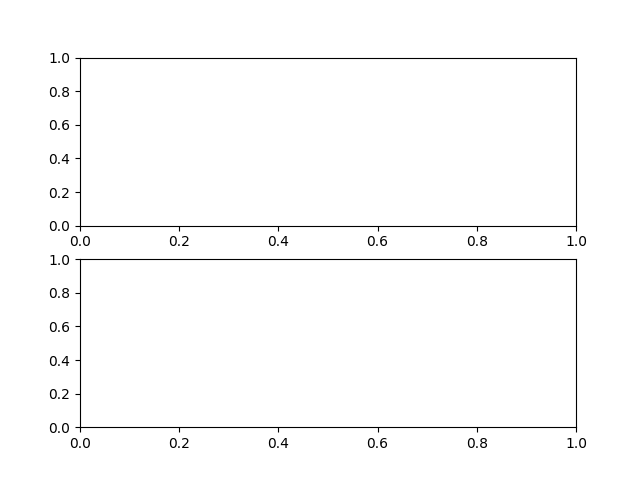

In [46]:
fig, axs = plt.subplots(2)

axs[0]
axs[1]

plt.show()

In [20]:
ax.xaxis.label._text

''

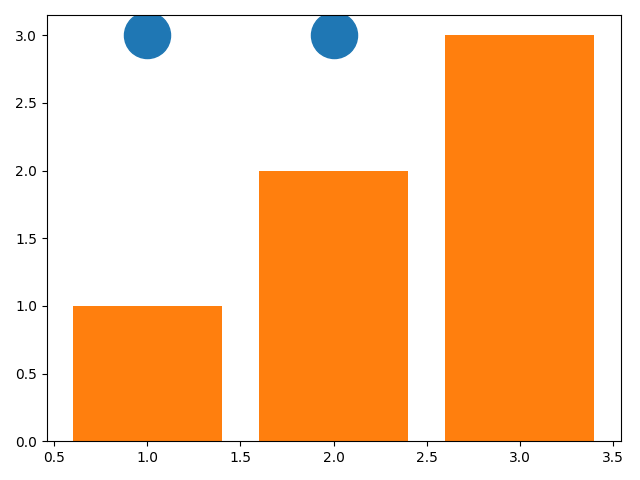

In [7]:
fig = plt.figure(layout='tight')
ax = fig.add_subplot(1, 1, 1)

paths = ax.scatter([1,2], [3,3], s=1100)
# paths2 = ax.plot([1,2], [1,2])
bars = ax.bar([1,2,3], [1,2,3])

plt.show()

In [6]:
print(ax.bar.__doc__)

Make a bar plot.

The bars are positioned at *x* with the given *align*\ment. Their
dimensions are given by *height* and *width*. The vertical baseline
is *bottom* (default 0).

Many parameters can take either a single value applying to all bars
or a sequence of values, one for each bar.

Parameters
----------
x : float or array-like
    The x coordinates of the bars. See also *align* for the
    alignment of the bars to the coordinates.

height : float or array-like
    The height(s) of the bars.

    Note that if *bottom* has units (e.g. datetime), *height* should be in
    units that are a difference from the value of *bottom* (e.g. timedelta).

width : float or array-like, default: 0.8
    The width(s) of the bars.

    Note that if *x* has units (e.g. datetime), then *width* should be in
    units that are a difference (e.g. timedelta) around the *x* values.

bottom : float or array-like, default: 0
    The y coordinate(s) of the bottom side(s) of the bars.

    Note that if *bott

In [40]:
import shapely

p1 = snp.box_around(1,2, 0.3)
p2 = snp.box_around(4,2, 0.3)
mp = shapely.union_all([p1,p2])

isinstance(mp, shapely.geometry.multipolygon.MultiPolygon)

True

In [48]:
mp.geoms[0].svg()

'<path fill-rule="evenodd" fill="#66cc99" stroke="#555555" stroke-width="2.0" opacity="0.6" d="M 0.7,1.7 L 0.7,2.3 L 1.3,2.3 L 1.3,1.7 L 0.7,1.7 z" />'

In [13]:
offsets = paths.get_offsets()
display_coords = ax.transData.transform(offsets)

# print(display_coords)

paths.axes ==ax
paths.get_children()

[]

In [90]:
groups = ['control', 'experiment']

durations = [
    [18, 15.42, 25.55, 12.56, 8.67],
    [7.31, 9.66, 13.64, 14.92, 18.47]
] # durations[0] corresponds to the `control` group, durations[1] corresponds to the `experiment` group

success = [
    [1, 1, 0, 0, 1],
    [0, 0, 1, 1, 1]
] # success[0] corresponds to the `control` group, success[1] corresponds to the `experiment` group

time_limit = 30

In [5]:
counts_lists = [
    [4, 1, 3, 6, 10],
    [1, 4, 4, 9, 6],
    [3, 5, 7, 7, 2],
]

In [6]:
counts = [4, 1, 3, 6, 10]

In [7]:
left_color  = (1, 0.4, 0.3)
right_color = (0, 0.5, 1)

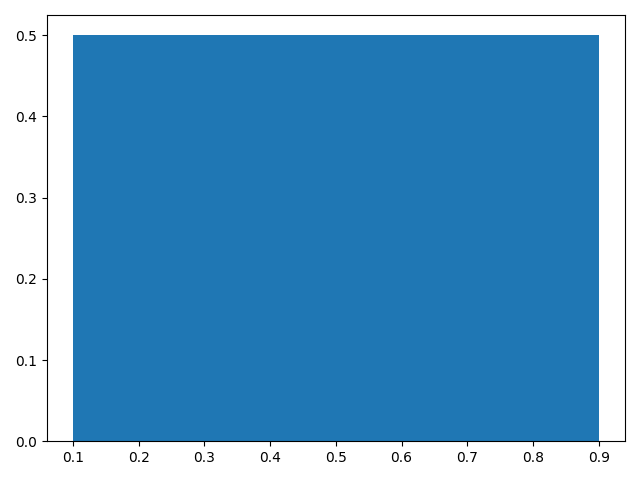

In [8]:
fig = plt.figure(layout='tight')
ax = fig.add_subplot(1, 1, 1)

bars = ax.bar(0.5, 0.5)

plt.show()

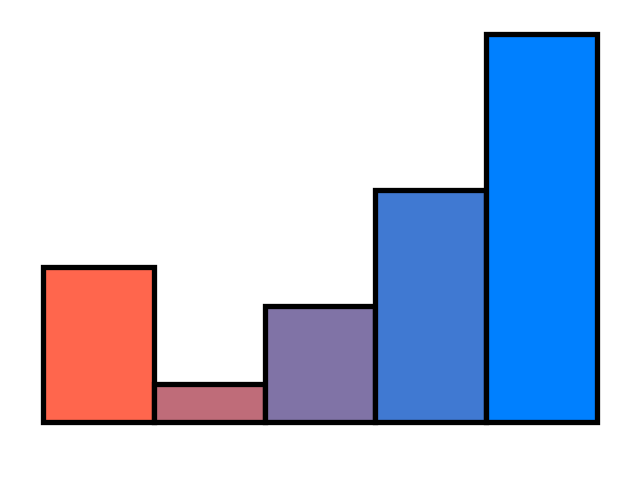

In [58]:
def plot_mini_hist(counts):
    fig = plt.figure(layout='tight')
    ax = fig.add_subplot(1, 1, 1, frameon=False)
    
    # Create gradients between left_color and right_color for each bar
    gradient_colors = [
        (
            left_color[0] + (right_color[0] - left_color[0]) * i / (len(counts) - 1),
            left_color[1] + (right_color[1] - left_color[1]) * i / (len(counts) - 1),
            left_color[2] + (right_color[2] - left_color[2]) * i / (len(counts) - 1)
        )
        for i in range(len(counts))
    ]

    bars2 = ax.bar(np.arange(len(counts)), counts, width=1, color=gradient_colors, edgecolor=(0.00, 0.00, 0.00), linewidth=3.8)
    ticks = ax.set_yticks([], minor=False)
    ticks2 = ax.set_xticks([])
    ax.set_ylim(bottom=-1.1)

    plt.show()

plot_mini_hist(counts[0])

In [ ]:
def plot_counts(counts, left_color, right_color, ci_lo, ci_hi):
    fig = plt.figure(layout='tight')
    ax = fig.add_subplot(1, 1, 1, frameon=False)
    
    # Interpolation of colors
    num_bars = len(counts)
    colors = [
        (
            left_color[0] + (right_color[0] - left_color[0]) * i / (num_bars - 1),
            left_color[1] + (right_color[1] - left_color[1]) * i / (num_bars - 1),
            left_color[2] + (right_color[2] - left_color[2]) * i / (num_bars - 1)
        ) for i in range(num_bars)
    ]
    
    bars = ax.bar(np.arange(num_bars), counts, color=colors, edgecolor=(0.00, 0.00, 0.00), linewidth=3, bottom=0.72, width=1)
    ax.set_ylim(bottom=0)
    ticks = ax.set_yticks([])
    ticks2 = ax.set_xticks([])
    # line_2d2 = ax.axvline(x=2, ymin=-0.1, ymax=0.12, color=(0.00, 0.00, 0.00), linewidth=3)
    polygon = ax.axvspan(ci_lo, ci_hi, ymin=0.025, ymax=0.11, color=(0.00, 0.00, 0.00))
    
    plt.show()

plot_counts(counts, left_color, right_color, 2.2, 3.8)

In [34]:
counts = [4, 0, 3, 6, 10]

left_color  = (1,0.4,0.3)
right_color = (0,0.5,1)

In [22]:
ax.spines.top

In [23]:
snp.methods_for(ax.spines.top)

([''], 'add_callback', float('inf'), "Add a callback function that will be called whenever one of the `.Artist`'s properties changes."),
([''], 'arc_spine', float('inf'), 'Create and return an arc `Spine`.'),
([''], 'axes', float('inf'), 'An Axes object encapsulates all the elements of an individual (sub-)plot in a figure.'),
([''], 'axis', float('inf'), ''),
([''], 'circular_spine', float('inf'), 'Create and return a circular `Spine`.'),
([''], 'clear', float('inf'), 'Clear the current spine.'),
([''], 'clipbox', float('inf'), ''),
([''], 'contains', float('inf'), 'Test whether the mouse event occurred in the patch.'),
([''], 'contains_point', float('inf'), 'Return whether the given point is inside the patch.'),
([''], 'contains_points', float('inf'), 'Return whether the given points are inside the patch.'),
([''], 'convert_xunits', float('inf'), 'Convert *x* using the unit type of the xaxis.'),
([''], 'convert_yunits', float('inf'), 'Convert *y* using the unit type of the yaxis.'),
(

In [ ]:
last_snp.figure.get_suptitle()
'last_snp.figure.axes[0].get_title()'

In [88]:
import ast

code = 'def f(x): pass'

ast.dump(ast.parse(code))

"Module(body=[FunctionDef(name='f', args=arguments(posonlyargs=[], args=[arg(arg='x')], kwonlyargs=[], kw_defaults=[], defaults=[]), body=[Pass()], decorator_list=[])], type_ignores=[])"

In [76]:
type(3.4).__name__

'float'

In [106]:
%%javascript

var x = `asdfasdf
     asdfasdf`;

console.log(x)

<IPython.core.display.Javascript object>

In [95]:
See("snp_ui.type_graph['builtins'].tree.names['list']")

In [45]:
# '__plottery_mypy_temp.make_fig'
# See('snp_ui.type_tree.defs[13]')

# See('snp_ui.mypy_result.types[snp_ui.type_tree.defs[14]]')

# [node.fullname for node in snp_ui.mypy_result.types.keys()]


# okay so this one has the func local definition names in it, as mypy.nodes.NameExpr with a .fullname attribue, but that .fullname is not fully qualified, it's the local name only
# also doesn't have func vars
# types are the vals of the dict
# See("list(snp_ui.mypy_result.types.keys())")

In [ ]:
__plottery_mypy_temp.make_fig

In [66]:
dir(snp_ui.type_graph['__plottery_mypy_temp'])

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__mypyc_attrs__',
 '__mypyc_defaults_setup',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '_patch_indirect_dependencies',
 '_type_checker',
 'abspath',
 'add_ancestors',
 'add_dependency',
 'ancestors',
 'caller_line',
 'caller_state',
 'check_blockers',
 'compute_dependencies',
 'compute_fine_grained_deps',
 'data',
 'dep_line_map',
 'dependencies',
 'dependencies_set',
 'dependency_lines',
 'dependency_priorities',
 'detect_possibly_undefined_vars',
 'early_errors',
 'externally_same',
 'fine_grained_deps_loaded',
 'finish_passes',
 'fix_cross_refs',
 'free_state',
 'generate_ignore_without_code_notes',
 'generate_unused_ignore_notes',
 'id',
 'ignore_all',

In [47]:
snp.notebook_as_code_module_name

'__plottery_mypy_temp'

In [84]:
# plt._get_backend_mod().show

for figure_manager in mpl._pylab_helpers.Gcf.get_all_fig_managers():
    print(figure_manager.canvas.figure)


#     show._to_draw = []
# finally:
#     show._to_draw = []

import matplotlib_inline

matplotlib_inline.backend_inline.show._to_draw


[]

In [160]:
list(paths3._paths[0].vertices)

[array([ 0. , -0.5]),
 array([ 0.13260155, -0.5       ]),
 array([ 0.25978994, -0.44731685]),
 array([ 0.35355339, -0.35355339]),
 array([ 0.44731685, -0.25978994]),
 array([ 0.5       , -0.13260155]),
 array([0.5, 0. ]),
 array([0.5       , 0.13260155]),
 array([0.44731685, 0.25978994]),
 array([0.35355339, 0.35355339]),
 array([0.25978994, 0.44731685]),
 array([0.13260155, 0.5       ]),
 array([0. , 0.5]),
 array([-0.13260155,  0.5       ]),
 array([-0.25978994,  0.44731685]),
 array([-0.35355339,  0.35355339]),
 array([-0.44731685,  0.25978994]),
 array([-0.5       ,  0.13260155]),
 array([-0.5,  0. ]),
 array([-0.5       , -0.13260155]),
 array([-0.44731685, -0.25978994]),
 array([-0.35355339, -0.35355339]),
 array([-0.25978994, -0.44731685]),
 array([-0.13260155, -0.5       ]),
 array([ 0. , -0.5]),
 array([ 0. , -0.5])]

Path(array([[ 0.        , -0.5       ],
       [ 0.13260155, -0.5       ],
       [ 0.25978994, -0.44731685],
       [ 0.35355339, -0.35355339],
       [ 0.44731685, -0.25978994],
       [ 0.5       , -0.13260155],
       [ 0.5       ,  0.        ],
       [ 0.5       ,  0.13260155],
       [ 0.44731685,  0.25978994],
       [ 0.35355339,  0.35355339],
       [ 0.25978994,  0.44731685],
       [ 0.13260155,  0.5       ],
       [ 0.        ,  0.5       ],
       [-0.13260155,  0.5       ],
       [-0.25978994,  0.44731685],
       [-0.35355339,  0.35355339],
       [-0.44731685,  0.25978994],
       [-0.5       ,  0.13260155],
       [-0.5       ,  0.        ],
       [-0.5       , -0.13260155],
       [-0.44731685, -0.25978994],
       [-0.35355339, -0.35355339],
       [-0.25978994, -0.44731685],
       [-0.13260155, -0.5       ],
       [ 0.        , -0.5       ],
       [ 0.        , -0.5       ]]), array([ 1,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        

In [101]:
fig.__class__

matplotlib.figure.Figure

In [100]:
See('ax.legend')

In [24]:
print(plt.figure.__doc__)


    Create a new figure, or activate an existing figure.

    Parameters
    ----------
    num : int or str or `.Figure` or `.SubFigure`, optional
        A unique identifier for the figure.

        If a figure with that identifier already exists, this figure is made
        active and returned. An integer refers to the ``Figure.number``
        attribute, a string refers to the figure label.

        If there is no figure with the identifier or *num* is not given, a new
        figure is created, made active and returned.  If *num* is an int, it
        will be used for the ``Figure.number`` attribute, otherwise, an
        auto-generated integer value is used (starting at 1 and incremented
        for each new figure). If *num* is a string, the figure label and the
        window title is set to this value.  If num is a ``SubFigure``, its
        parent ``Figure`` is activated.

    figsize : (float, float), default: :rc:`figure.figsize`
        Width, height in inches.

    dpi :

In [6]:
colors_t = mypy.types.get_proper_type(snp.type_graph['__temp'].tree.names['colors'].type)
colors_t

builtins.list[builtins.str]

In [7]:
colors_arg_t = mypy.types.get_proper_type(snp.type_graph['matplotlib.axes._axes'].tree.names['Axes'].node.names['bar'].type.arg_types[6])
colors_arg_t

typing.Sequence[Union[builtins.int, builtins.str]]

In [8]:
mypy.subtypes.is_subtype(colors_t, colors_arg_t)

1

In [29]:
mypy.types.get_proper_type(snp.type_graph['__temp'].tree.names['square_wave'].type)

Any

In [6]:
import mypy.api
from mypy import build
from mypy.options import Options
from mypy.nodes import FuncDef
from visitor_mypy import TraverserVisitor

# Example code containing the function we want to analyze
example_code = """
def example_function(a: int, b: str) -> str:
    c = a + 5
    d = b.upper()
    return d
"""

class VariableTypeVisitor(TraverserVisitor):
    def __init__(self, type_map, scope):
        self.type_map = type_map
        self.scope = scope

    def visit_func_def(self, def_node: FuncDef):
        print('hi')
        if def_node.fullname == self.scope:
            for var, typ in self.type_map.items():
                if var.startswith(def_node.fullname):
                    local_name = var.split('.')[-1]
                    print(f"{local_name}: {typ}")

def analyze_code(code: str, scope: str):
    # Parse the code using MyPy
    options = Options()
    options.show_traceback = True
    result = build.build(sources=[build.BuildSource(None, '__main__', code)], options=options)
    if result.errors:
        for error in result.errors:
            print(error)
        return

    # Get the symbol table (type map)
    type_map = result.types

    # Use a visitor to find the function of interest
    visitor = VariableTypeVisitor(type_map, scope)
#     print(result.files.values())
    for file in result.files.values():
        visitor.visit_mypy_file(file)

# Analyze the example code
analyze_code(example_code, 'example_function')